In [6]:
# Criar função para ter visão inicial das bases que estamos trabalhando:

def overview(df, name):
    print(f"--- {name} ---")
    display(df.head())
    print(df.info())
    print("\nValores nulos (%):")
    print((df.isna().mean() * 100).round(2))

overview(products, "Produtos")
overview(sellers, "Sellers")

--- Produtos ---


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None

Valores nulos (%):
product_id                    0.00
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weigh

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
None

Valores nulos (%):
seller_id                 0.0
seller_zip_code_prefix    0.0
seller_city               0.0
seller_state              0.0
dtype: float64


In [7]:
#Correção de nomeclatura da base

products = products.merge(
    category_translation,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

products["category"] = products["product_category_name_english"].fillna("unknown")

In [8]:
#Criação de métricas lógisticas dos produtos analisados
#Inisights: isso impacta em movimentação logística e pode gerar atrasos? Custo também é maior?

products["volume_cm3"] = (
    products["product_length_cm"] *
    products["product_height_cm"] *
    products["product_width_cm"]
)

products["weight_kg"] = products["product_weight_g"] / 1000


In [9]:
#Classificando os produtos logisticamente

products["weight_class"] = pd.cut(
    products["weight_kg"],
    bins=[0, 1, 5, 20, np.inf],
    labels=["Leve", "Médio", "Pesado", "Muito Pesado"]
)

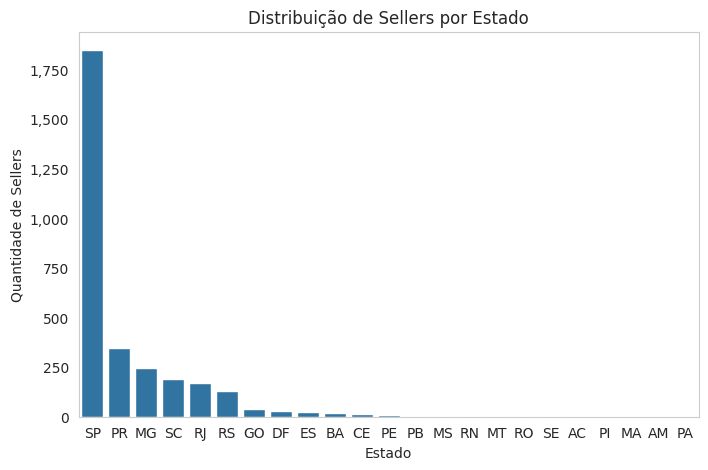

In [19]:
#Análise geográfica dos sellers

sellers_by_state = sellers["seller_state"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=sellers_by_state.index, y=sellers_by_state.values)
plt.title("Distribuição de Sellers por Estado")
plt.xlabel("Estado")
plt.grid(axis="y")
plt.ylabel("Quantidade de Sellers")

# Formatando os valores do eixo Y com separador de milhar
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

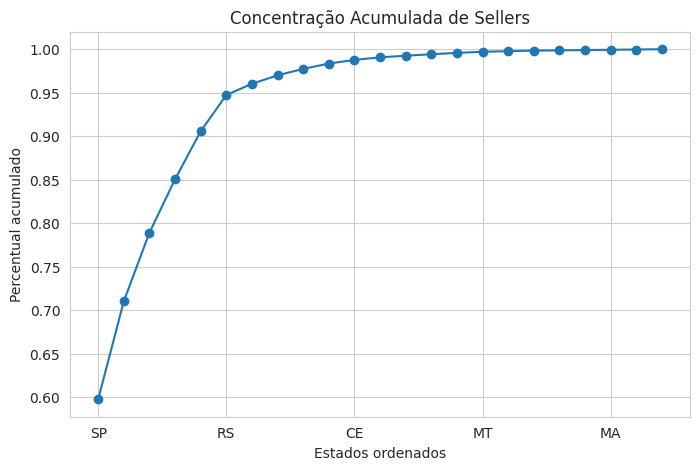

In [20]:


#Análise de pareto de estados que concentram vendedores

cum_dist = sellers_by_state.cumsum() / sellers_by_state.sum()

plt.figure(figsize=(8,5))
cum_dist.plot(marker="o")
plt.title("Concentração Acumulada de Sellers")
plt.ylabel("Percentual acumulado")
plt.xlabel("Estados ordenados")
plt.show()


#Insights -> muito se concentra no sudeste, o que gera um barateio se a concentração de clientes for maior na mesma região. No entanto, locais mais afastados, vão incrementar o custo logísitco, reduzindo margem.

In [21]:
import glob
import pandas as pd

# Lista todos os arquivos CSV no diretório atual
excel_files = glob.glob('*.csv') # Altere para '*.xls' se seus arquivos forem .xls, ou use ['**.xlsx', '**.xls'] para ambos

print(f"Arquivos CSV encontrados: {excel_files}")

# Verifica se há arquivos CSV para processar
if not excel_files:
    print("Nenhum arquivo CSV encontrado. Por favor, certifique-se de que os arquivos estão no diretório correto ou atualize o caminho.")

# Cria um DataFrame vazio para armazenar os dados combinados
all_data = pd.DataFrame()

# Itera sobre cada arquivo CSV, lê e concatena ao DataFrame principal
for f in excel_files:
    try:
        df = pd.read_csv(f)
        all_data = pd.concat([all_data, df], ignore_index=True)
    except Exception as e:
        print(f"Erro ao ler o arquivo {f}: {e}")


Arquivos CSV encontrados: []
Nenhum arquivo CSV encontrado. Por favor, certifique-se de que os arquivos estão no diretório correto ou atualize o caminho.


In [7]:

# Instalação da biblioteca pyxlsb para leitura de arquivos .xlsb
!pip install pyxlsb

import pandas as pd
import numpy as np
from google.colab import files
import os  # Para verificar a existência de arquivos
from pyxlsb import open_workbook

# =====================================================
# FUNÇÃO SEGURA PARA LIMPEZA DE VALORES NUMÉRICOS
# =====================================================

def clean_numeric(series):
    s = series.astype(str).str.strip().str.replace(' ', '', regex=False)
    result = pd.Series(np.nan, index=s.index)

    has_comma = s.str.contains(',', regex=False)
    has_dot   = s.str.contains(r'\.', regex=True)

    both = has_comma & has_dot
    is_br = both & (s.str.rfind(',') > s.str.rfind('.'))
    is_us = both & (s.str.rfind('.') > s.str.rfind(','))

    br_vals = s[is_br].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    result[is_br] = pd.to_numeric(br_vals, errors='coerce')

    us_vals = s[is_us].str.replace(',', '', regex=False)
    result[is_us] = pd.to_numeric(us_vals, errors='coerce')

    only_comma = has_comma & ~has_dot
    comma_vals = s[only_comma].str.replace(',', '.', regex=False)
    result[only_comma] = pd.to_numeric(comma_vals, errors='coerce')

    remaining = result.isna()
    result[remaining] = pd.to_numeric(s[remaining], errors='coerce')

    return result

# =====================================================
# FUNÇÃO PARA LER ARQUIVOS XLSB
# =====================================================
def read_xlsb(file_path):
    with open_workbook(file_path) as wb:
        with wb.get_sheet(1) as sheet:
            data = [row for row in sheet.rows()]
    return pd.DataFrame(data[1:], columns=data[0])

# =====================================================
# 1. ESCOLHA DE CARGA DOS ARQUIVOS
# =====================================================
print("Você deseja fazer upload de novos arquivos CSV (digite 'u') ou usar os arquivos CSV do Olist já presentes no ambiente (digite 'e')?")
choice = input("Digite 'u' para upload ou 'e' para usar existentes: ").strip().lower()

if choice == 'u':
    print("📥 Faça upload das 9 bases CSV do Olist:")
    uploaded = files.upload()
    print("✅ Upload de arquivos concluído.")
elif choice == 'e':
    print("✅ Usando arquivos CSV do Olist existentes no ambiente.")
else:
    print("⚠️ Escolha inválida. Usando arquivos existentes por padrão.")
    choice = 'e'  # Padrão para arquivos existentes se a entrada for inválida

# =====================================================
# 2. CARGA DAS BASES
# =====================================================
try:
    orders = pd.read_csv("olist_orders_dataset.csv")
    order_items = pd.read_csv("olist_order_items_dataset.csv")
    products = pd.read_csv("olist_products_dataset.csv")
    customers = pd.read_csv("olist_customers_dataset.csv")
    sellers = pd.read_csv("olist_sellers_dataset.csv")
    payments = pd.read_csv("olist_order_payments_dataset.csv")
    reviews = pd.read_csv("olist_order_reviews_dataset.csv")
    category_translation = pd.read_csv("product_category_name_translation.csv")
    geolocation = pd.read_csv("olist_geolocation_dataset.csv")
    print("✅ Bases carregadas com sucesso")
except FileNotFoundError as e:
    print(f"❌ Erro ao carregar arquivo: {e}. Certifique-se de que os arquivos estão presentes ou faça o upload.")
    raise
except Exception as e:
    print(f"❌ Erro inesperado ao carregar bases: {e}")
    raise

# =====================================================
# 3. TRATAMENTO DA BASE DE PRODUTOS
# =====================================================
products = products.merge(
    category_translation,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)
products["category"] = products["product_category_name_english"].fillna("unknown")
products["weight_kg"] = products["product_weight_g"] / 1000
products["volume_cm3"] = (
    products["product_length_cm"] *
    products["product_height_cm"] *
    products["product_width_cm"]
)
products["weight_class"] = pd.cut(
    products["weight_kg"],
    bins=[0, 1, 5, 20, np.inf],
    labels=["Leve", "Médio", "Pesado", "Muito Pesado"]
)

# =====================================================
# 4. LIMPEZA ROBUSTA DE VALORES FINANCEIROS
# =====================================================
order_items["price"] = clean_numeric(order_items["price"])
order_items["freight_value"] = clean_numeric(order_items["freight_value"])
payments["payment_value"] = clean_numeric(payments["payment_value"])

# =====================================================
# 5. AGREGAÇÃO DE PAGAMENTOS
# =====================================================
payments_agg = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_types=("payment_type", lambda x: ",".join(x.unique())),
        installments=("payment_installments", "max")
    )
    .reset_index()
)

# =====================================================
# 6. AGREGAÇÃO DE REVIEWS
# =====================================================
reviews_agg = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        review_comment_qty=("review_comment_message", lambda x: x.notna().sum())
    )
    .reset_index()
)

# =====================================================
# 7. CONSOLIDAÇÃO PRINCIPAL
# =====================================================
df = order_items.merge(products, how="left", on="product_id")
df = df.merge(sellers, how="left", on="seller_id")
df = df.merge(orders, how="left", on="order_id")
df = df.merge(customers, how="left", on="customer_id")
df = df.merge(payments_agg, how="left", on="order_id")
df = df.merge(reviews_agg, how="left", on="order_id")

print(f"✅ Base consolidada criada | Shape: {df.shape}")

# =====================================================
# 8. FEATURE ENGINEERING
# =====================================================
df["revenue_item"] = df["price"] + df["freight_value"]
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])

df["delivery_time_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

df["delayed"] = df["delivery_time_days"] > 10

# =====================================================
# 9. BASE FINAL ANALÍTICA
# =====================================================
final_columns = [
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "customer_state",
    "seller_id",
    "seller_state",
    "product_id",
    "category",
    "weight_kg",
    "volume_cm3",
    "weight_class",
    "price",
    "freight_value",
    "revenue_item",
    "payment_value",
    "payment_types",
    "installments",
    "review_score",
    "review_comment_qty", # Adicionando esta coluna
    "delivery_time_days",
    "delayed"
]

df_final = df[final_columns]

# =====================================================
# FORMATAÇÃO DOS NÚMEROS
# =====================================================
def format_currency(value):
    """Formata o valor numérico para o padrão brasileiro (ex: 58,90)."""
    if pd.isna(value):
        return ""
    return f"{value:,.2f}".replace('.', ',')  # Substitui o ponto pela vírgula

df_final["price"] = df_final["price"].apply(format_currency)
df_final["freight_value"] = df_final["freight_value"].apply(format_currency)
df_final["revenue_item"] = df_final["revenue_item"].apply(format_currency)
df_final["payment_value"] = df_final["payment_value"].apply(format_currency)

print("✅ Base analítica final pronta")

# =====================================================
# 10. EXPORTAÇÃO E DOWNLOAD
# =====================================================
df_final.to_csv("olist_analytical_base.csv", index=False)
df_final.to_parquet("olist_analytical_base.parquet", index=False)

files.download("olist_analytical_base.csv")
files.download("olist_analytical_base.parquet")

# =====================================================
# 11. VALIDAÇÃO FINAL (OBRIGATÓRIA)
# =====================================================
df_final[["price", "freight_value", "revenue_item"]].sample(10)

Você deseja fazer upload de novos arquivos CSV (digite 'u') ou usar os arquivos CSV do Olist já presentes no ambiente (digite 'e')?
Digite 'u' para upload ou 'e' para usar existentes: u
📥 Faça upload das 9 bases CSV do Olist:


Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv
✅ Upload de arquivos concluído.
✅ Bases carregadas com sucesso
✅ Base consolidada criada | Shape: (112650, 39)


/tmp/ipykernel_21672/3131904614.py:206: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["price"] = df_final["price"].apply(format_currency)
/tmp/ipykernel_21672/3131904614.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["freight_value"] = df_final["freight_value"].apply(format_currency)
/tmp/ipykernel_21672/3131904614.py:208: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

✅ Base analítica final pronta


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,price,freight_value,revenue_item
79493,"18,90","34,15","53,05"
47337,"219,99","32,98","252,97"
32291,"95,28","18,91","114,19"
92181,"49,00","14,58","63,58"
35123,"159,00","29,63","188,63"
103314,"682,98","27,36","710,34"
45199,"16,00","5,29","21,29"
76522,"19,83","12,80","32,63"
36540,"170,00","24,06","194,06"
71466,"29,90","17,93","47,83"


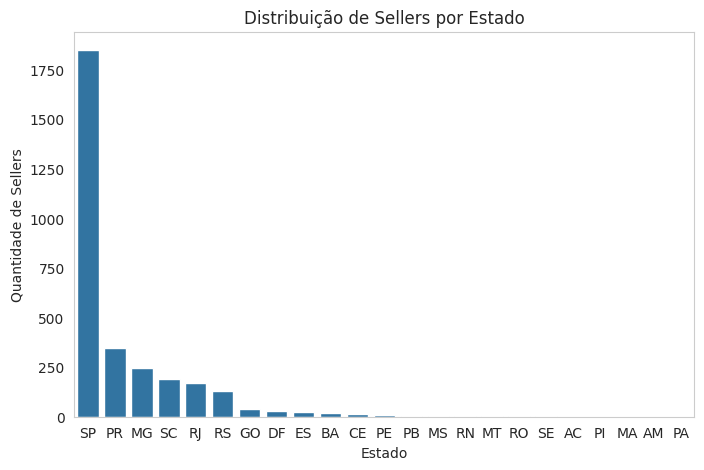

In [22]:
# =====================================================
# Análise geográfica dos sellers
# =====================================================

sellers_by_state = sellers["seller_state"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=sellers_by_state.index, y=sellers_by_state.values)
plt.title("Distribuição de Sellers por Estado")
plt.xlabel("Estado")
plt.grid(False)
plt.ylabel("Quantidade de Sellers")
plt.show()

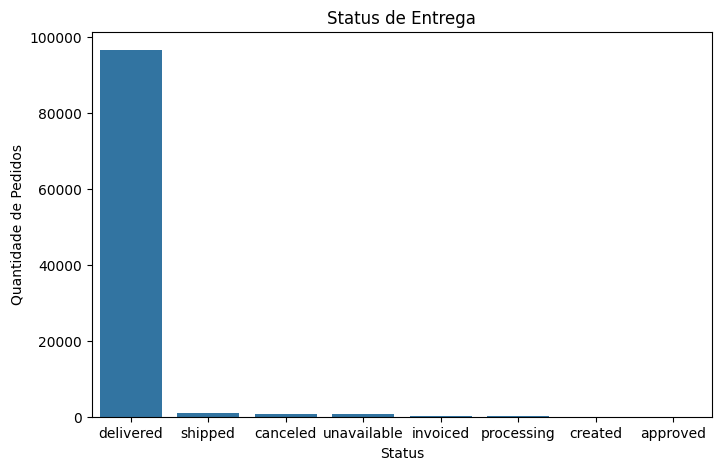

In [9]:
# =====================================================
# Análise dos status de Pedidos
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

status_pedidos = orders['order_status'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=status_pedidos.index, y=status_pedidos.values)
plt.title("Status de Entrega")
plt.xlabel("Status")
plt.grid(False)
plt.ylabel("Quantidade de Pedidos")
plt.show()

In [10]:
# =====================================================
# Importação base tratada Bruno
# =====================================================

import pandas as pd
import numpy as np
df_excel = pd.read_excel('/content/olist_tabela_final_completa_G27.xlsx')

KeyboardInterrupt: 

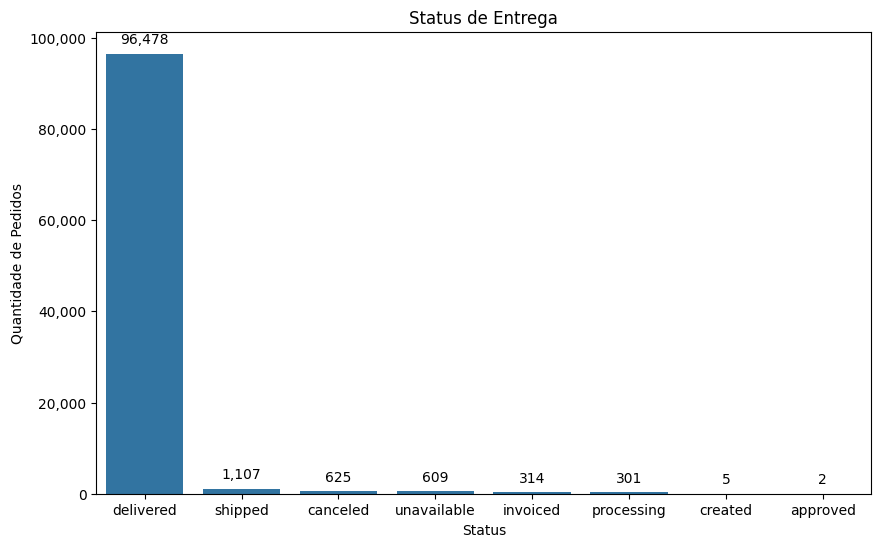

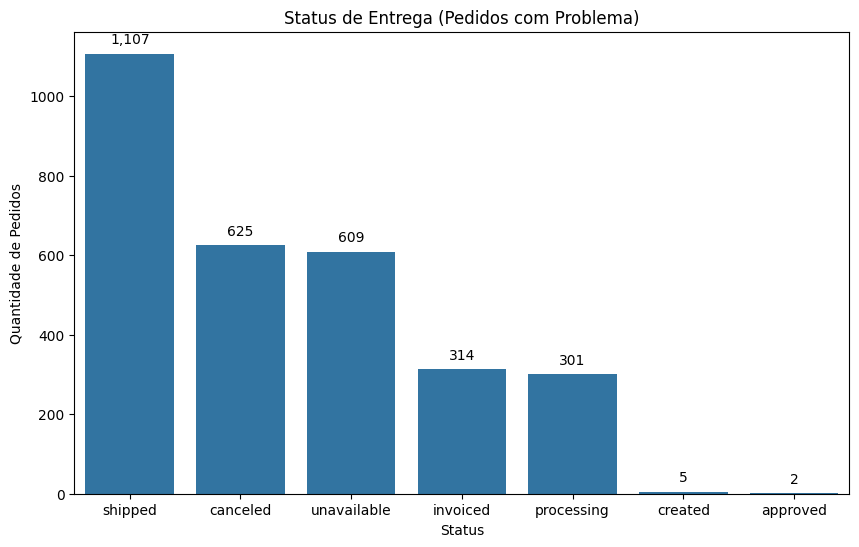

In [12]:
# =====================================================
# Análise NPS - Pedidos totais
# =====================================================


status_pedidos = orders['order_status'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=status_pedidos.index, y=status_pedidos.values)
plt.title("Status de Entrega")
plt.xlabel("Status")
plt.grid(False)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.ylabel("Quantidade de Pedidos")
# Adicionar os rótulos nas barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.show()

# =====================================================
# Análise NPS - Pedidos com problemas
# =====================================================

# Filtrar pedidos para excluir o status 'delivered'
orders_filtered_for_plot = orders[orders['order_status'] != 'delivered']

# Recalcular a contagem de status para o gráfico
status_pedidos_filtered = orders_filtered_for_plot['order_status'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=status_pedidos_filtered.index, y=status_pedidos_filtered.values)
plt.title("Status de Entrega (Pedidos com Problema)")
plt.xlabel("Status")
plt.grid(False)
plt.ylabel("Quantidade de Pedidos")

# Adicionar os rótulos nas barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.show()

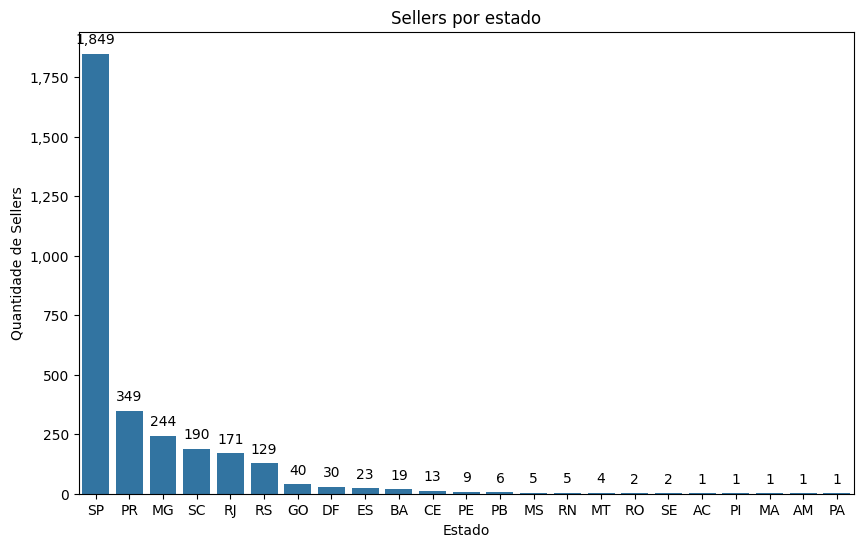

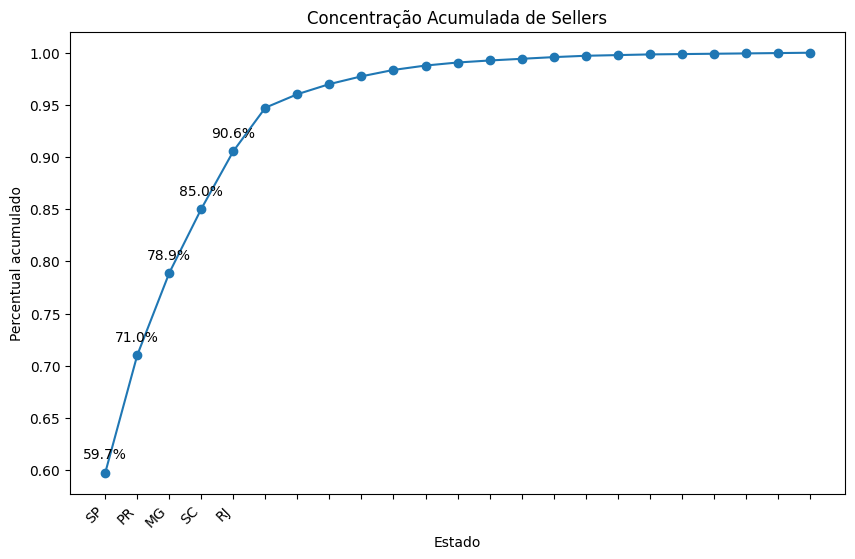

In [18]:
# =====================================================
# Análise Vendedores
# =====================================================

# Consolidando as colunas que serão usadas
sellers_por_estado = sellers['seller_state'].value_counts()

# Plotando o gráfico:
# Define o tamanho da figura
# Usa a função ax para adicionar rótulos de dados (data labels)
# Define os rótulos para os eixos


plt.figure(figsize=(10,6))
ax = sns.barplot(x=sellers_por_estado.index, y=sellers_por_estado.values)
plt.title("Sellers por estado")
plt.xlabel("Estado")
plt.grid(False)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.ylabel("Quantidade de Sellers")
# Adiciona os rótulos de dados (valores) nas barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')
plt.show()

# =====================================================
# Análise Vendedores - Pareto de localização
# =====================================================


# Visibilidade do Pareto de estados que concentram os sellers

sellers_by_state = sellers["seller_state"].value_counts()

cum_dist = sellers_by_state.cumsum() / sellers_by_state.sum() # Remove .head(5) to show full Pareto

plt.figure(figsize=(10,6))
ax = cum_dist.plot(marker="o")
plt.title("Concentração Acumulada de Sellers") # Título do gráfico
plt.ylabel("Percentual acumulado")
plt.xlabel("Estado") # Rótulo do eixo x
plt.grid(False)

# Obtém todos os nomes dos estados do índice
all_state_names = cum_dist.index.tolist()
# Obtém as posições numéricas para todos os estados
all_state_indices = list(range(len(all_state_names)))

# Cria uma lista de rótulos para o eixo x: nome para os 5 primeiros, string vazia para o resto
x_tick_labels = [state_name if i < 5 else '' for i, state_name in enumerate(all_state_names)]

# Define os ticks do eixo x para todas as posições numéricas
ax.set_xticks(all_state_indices)
# Define os rótulos personalizados do eixo x, rotacionando para melhor legibilidade
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')

# Adiciona os rótulos aos pontos da linha (somente os 5 primeiros)
for i, (state, value) in enumerate(cum_dist.head(5).items()): # Itera apenas sobre os 5 primeiros itens para os rótulos
    ax.annotate(f'{value:.1%}', # Formata como percentual com uma casa decimal
                (i, value), # Usa o índice numérico 'i' para a coordenada x
                textcoords="offset points",
                xytext=(0,10), # Deslocamento do rótulo em relação ao ponto
                ha='center')

plt.show()

,order_status,review_score,total_reviews
3,delivered,4.155717,39099
0,approved,2.500000,0
2,created,2.333333,2
6,shipped,2.008629,634
1,canceled,1.811166,406
4,invoiced,1.661342,214
7,unavailable,1.530988,415
5,processing,1.277027,207


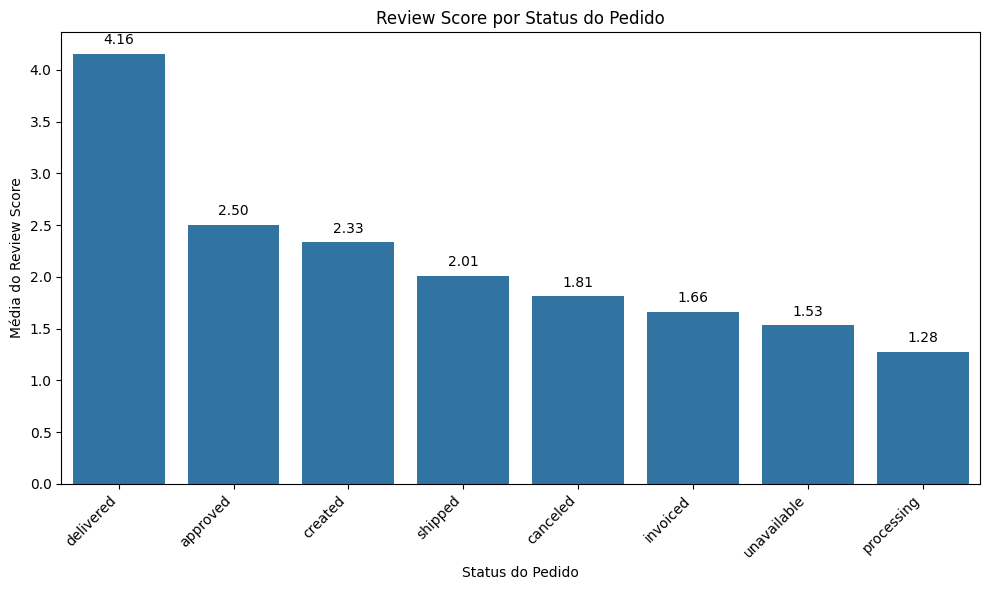

In [19]:
# =====================================================
# Score por status de Pedidos
# =====================================================

# Calcular a média do review_score e a soma do review_comment_qty por order_status
review_score_by_status = (
    df_excel.groupby('order_status')
    .agg(
        review_score=('review_score', 'mean'),
        total_reviews=('review_comment_message', lambda x: x.notna().sum())
    )
    .reset_index()
)

# Ordenar o DataFrame antes de exibir
review_score_by_status_sorted = review_score_by_status.sort_values(by='review_score', ascending=False)
display(review_score_by_status_sorted)

# Opcionalmente, você pode visualizar esses dados em um gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='order_status', y='review_score', data=review_score_by_status_sorted)
plt.title('Review Score por Status do Pedido')
plt.xlabel('Status do Pedido')
plt.ylabel('Média do Review Score')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()

# Adiciona os rótulos de dados (média do review score) nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', # Formatando para duas casas decimais
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')


plt.show()

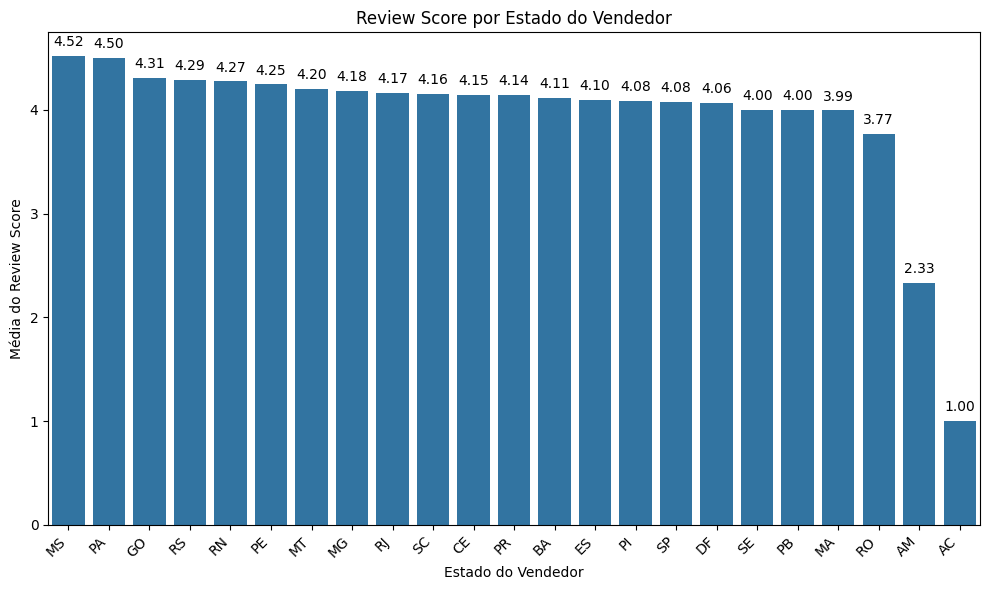

In [33]:
# =====================================================
# Review por estado -
# =====================================================

# Calcular a média do review_score por estado do vendedor
review_score_by_seller_state = (
    df_excel.groupby('seller_state')['review_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plotar a média do review_score por estado do vendedor
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='seller_state',
    y='review_score',
    data=review_score_by_seller_state,
)

plt.title('Review Score por Estado do Vendedor')
plt.xlabel('Estado do Vendedor')
plt.ylabel('Média do Review Score')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()

# Adicionar os rótulos de dados (média do review score) nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', # Formatando para duas casas decimais
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.show()

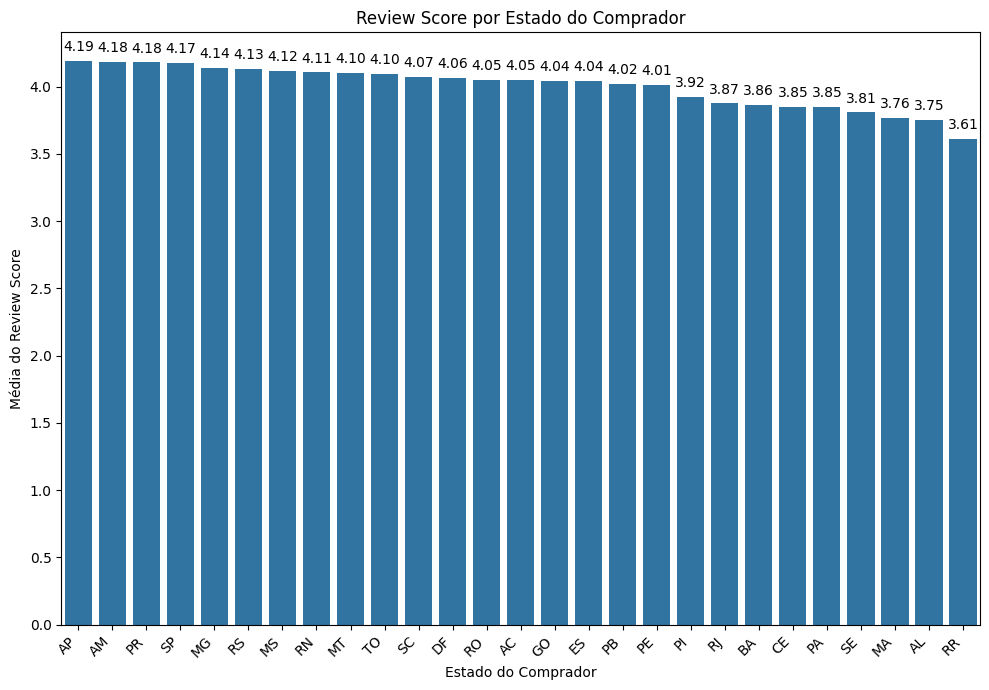

In [29]:
# =====================================================
# Análise Compradores
# =====================================================

# Calcular a média do review_score por estado do Comprador
review_score_by_seller_state = (
    df_excel.groupby('customer_state')['review_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plotar a média do review_score por estado do vendedor
plt.figure(figsize=(10, 7))
ax = sns.barplot(
    x='customer_state',
    y='review_score',
    data=review_score_by_seller_state,
)

plt.title('Review Score por Estado do Comprador')
plt.xlabel('Estado do Comprador')
plt.ylabel('Média do Review Score')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()

# Adicionar os rótulos de dados (média do review score) nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', # Formatando para duas casas decimais
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.show()

In [30]:
df_excel.head(5)


,chave_order,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_city,...,freight_value,seller_id,seller_city,seller_state,payment_sequential,payment_type,payment_value,payment_installments,review_score,review_comment_message
0,1,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,9ef432eb6251297304e76186b10a928d,sao paulo,...,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,1.0,credit_card,18.12,1.0,4.0,"NÃ£o testei o produto ainda, mas ele veio corr..."
1,2,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,9ef432eb6251297304e76186b10a928d,sao paulo,...,NaN,NaN,NaN,NaN,3.0,voucher,2.00,1.0,NaN,NaN
2,3,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,9ef432eb6251297304e76186b10a928d,sao paulo,...,NaN,NaN,NaN,NaN,2.0,voucher,18.59,1.0,NaN,NaN
3,1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,...,22.76,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,1.0,boleto,141.46,1.0,4.0,Muito bom o produto.
4,1,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,41ce2a54c0b03bf3443c3d931a367089,vianopolis,...,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1.0,credit_card,179.12,3.0,5.0,NaN


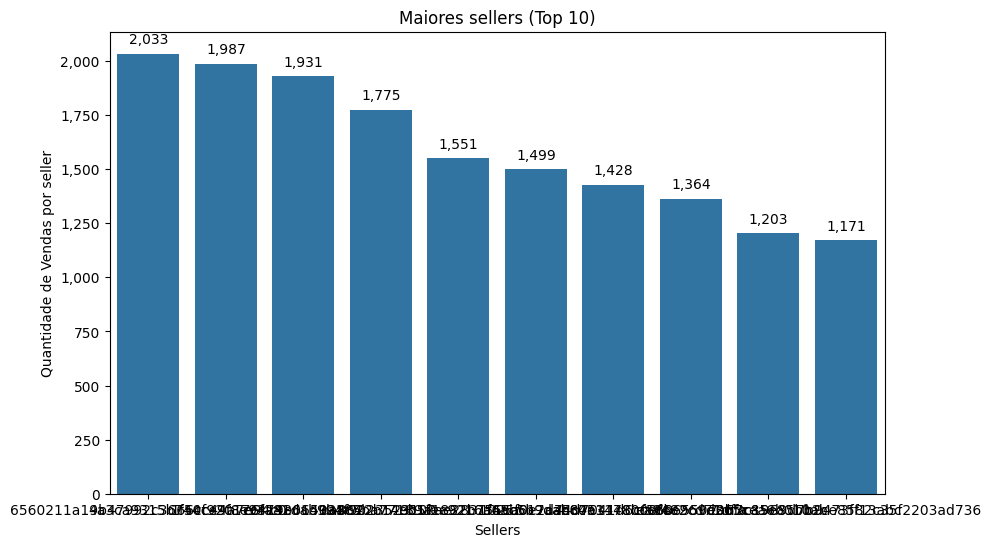

In [34]:
# =====================================================
# Maiores vendedores
# =====================================================

# Encontrar maiores vendedores e ver quanto representam nas vendas
maiores_sellers = df_excel['seller_id']

# Ordenar os dados antes de exibir e pegar os 10 maiores
maiores_sellers = maiores_sellers.value_counts().head(10)

# Plotando o gráfico:
# Define o tamanho da figura
# Usa a função ax para adicionar rótulos de dados (data labels)
# Define os rótulos para os eixos


plt.figure(figsize=(10,6))
ax = sns.barplot(x=maiores_sellers.index, y=maiores_sellers.values)
plt.title("Maiores sellers (Top 10)")
plt.xlabel("Sellers")
plt.grid(False)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.ylabel("Quantidade de Vendas por seller")
# Adiciona os rótulos de dados (valores) nas barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')
plt.show()

Tabela de Mapeamento de Sellers:


,Rótulo do Seller,ID do Seller,Quantidade de Vendas
0,Seller 1,6560211a19b47992c3666cc44a7e94c0,2033
1,Seller 2,4a3ca9315b744ce9f8e9374361493884,1987
2,Seller 3,1f50f920176fa81dab994f9023523100,1931
3,Seller 4,cc419e0650a3c5ba77189a1882b7556a,1775
4,Seller 5,da8622b14eb17ae2831f4ac5b9dab84a,1551
5,Seller 6,955fee9216a65b617aa5c0531780ce60,1499
6,Seller 7,1025f0e2d44d7041d6cf58b6550e0bfa,1428
7,Seller 8,7c67e1448b00f6e969d365cea6b010ab,1364
8,Seller 9,ea8482cd71df3c1969d7b9473ff13abc,1203
9,Seller 10,7a67c85e85bb2ce8582c35f2203ad736,1171


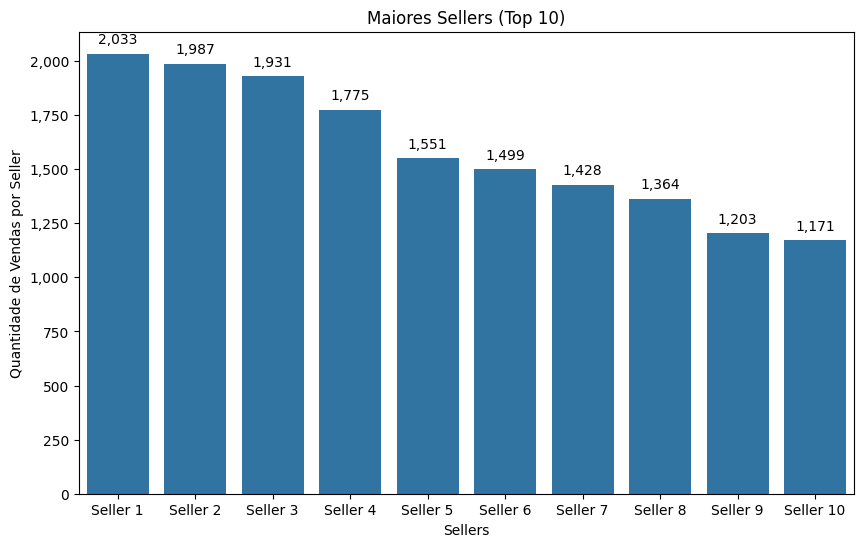

In [35]:
# =====================================================
# Maiores vendedores
# =====================================================

# Criar um mapeamento de seller_id para rótulos genéricos 'Seller N'
seller_labels = [f'Seller {i+1}' for i in range(len(maiores_sellers))]

# Criar um DataFrame para a tabela de mapeamento
seller_mapping_table = pd.DataFrame({
    'Rótulo do Seller': seller_labels,
    'ID do Seller': maiores_sellers.index,
    'Quantidade de Vendas': maiores_sellers.values
})

# Exibir a tabela de mapeamento
print("Tabela de Mapeamento de Sellers:")
display(seller_mapping_table)

# Plotar o gráfico com os novos rótulos
plt.figure(figsize=(10,6))
ax = sns.barplot(x=seller_labels, y=maiores_sellers.values)
plt.title("Maiores Sellers (Top 10)")
plt.xlabel("Sellers")
plt.grid(False)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.ylabel("Quantidade de Vendas por Seller")
# Adiciona os rótulos de dados (valores) nas barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')
plt.show()

In [37]:
# =====================================================
# Calculando leadtimes
# =====================================================

# Criar o novo dataframde
df_ajustado = df_excel.copy()

# Converter as colunas de data para o formato datetime
df_ajustado['order_delivered_customer_date'] = pd.to_datetime(df_ajustado['order_delivered_customer_date'], errors='coerce')
df_ajustado['order_approved_at'] = pd.to_datetime(df_ajustado['order_approved_at'], errors='coerce')
df_ajustado['order_estimated_delivery_date'] = pd.to_datetime(df_ajustado['order_estimated_delivery_date'], errors='coerce')

# Calcular lead_real e lead_teorico em dias e arredondar para 1 casa decimal
df_ajustado['lead_real'] = (
    (df_ajustado['order_delivered_customer_date'] - df_ajustado['order_approved_at']).dt.total_seconds() / (24 * 3600)
).round(1)

df_ajustado['lead_teorico'] = (
    (df_ajustado['order_estimated_delivery_date'] - df_ajustado['order_approved_at']).dt.total_seconds() / (24 * 3600)
).round(1)


# Exibir as novas colunas e as colunas originais para verificação
display(df_ajustado[[
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'lead_real',
    'lead_teorico'
]].head())

,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,lead_real,lead_teorico
0,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18,8.4,15.5
1,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18,8.4,15.5
2,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18,8.4,15.5
3,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13,12.5,17.9
4,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04,9.4,26.6


,order_status,mean_lead_real,percentual_atrasado
3,delivered,12.059022,48.518712
1,canceled,18.057143,0.534759
0,approved,NaN,0.000000
2,created,NaN,0.000000
4,invoiced,NaN,0.000000
5,processing,NaN,0.000000
6,shipped,NaN,0.000000
7,unavailable,NaN,0.000000


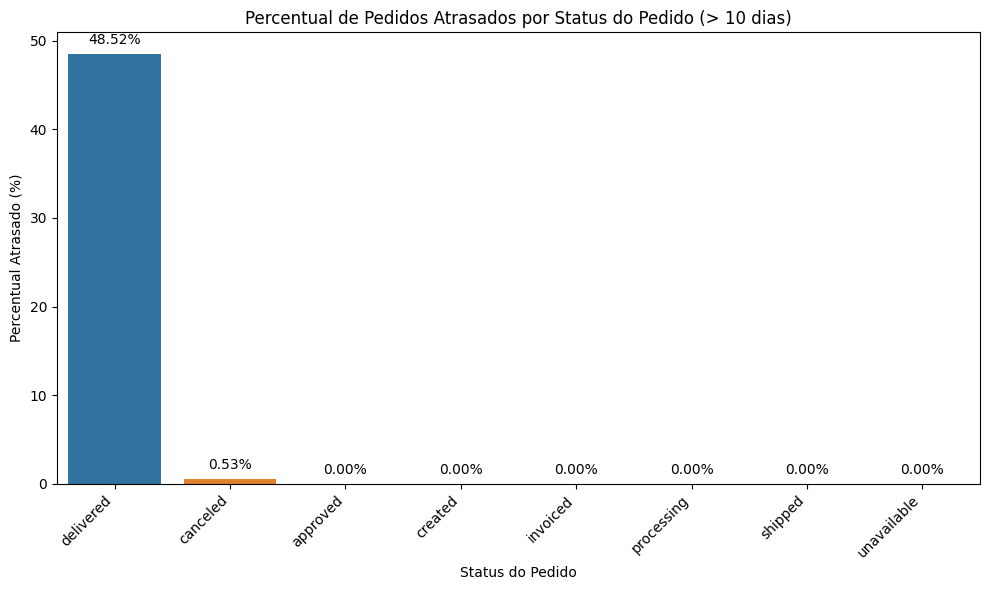

In [42]:
# =====================================================
# Percentual de Pedidos fora do leadtime
# =====================================================

# Calcular a % de pedidos que ultrapassaram os 10 dias de entrega por status de pedidos
leadtime_pedidos = (
    df_ajustado.groupby('order_status')
    .agg(
        mean_lead_real=('lead_real', 'mean'),
        percentual_atrasado=('lead_real', lambda x: (x > 10).mean() * 100) # Calcula a porcentagem
    )
    .reset_index()
)

# Ordenar o DataFrame pelo percentual de atraso antes de exibir
leadtime_pedidos = leadtime_pedidos.sort_values(by='percentual_atrasado', ascending=False)
display(leadtime_pedidos)

# Visualização dos dados:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='order_status', y='percentual_atrasado', data=leadtime_pedidos, hue='order_status', legend=False)
plt.title('Percentual de Pedidos Atrasados por Status do Pedido (> 10 dias)')
plt.xlabel('Status do Pedido')
plt.ylabel('Percentual Atrasado (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()

# Adiciona os rótulos de dados (percentual) nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', # Formatando para duas casas decimais com símbolo de percentual
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.show()

NameError: name 'customer_state' is not defined

,order_status,customer_state,media_lead_real,percentual_atrasado
30,delivered,AC,19.998936,97.872340
33,delivered,AP,27.385542,97.590361
31,delivered,AL,24.137753,95.280899
39,delivered,MA,21.088780,91.961023
43,delivered,PA,23.220403,91.857274
32,delivered,AM,26.119412,91.764706
50,delivered,RO,19.171530,91.103203
35,delivered,CE,20.457181,88.881402
44,delivered,PB,19.982362,88.187702
54,delivered,SE,20.956545,87.958115


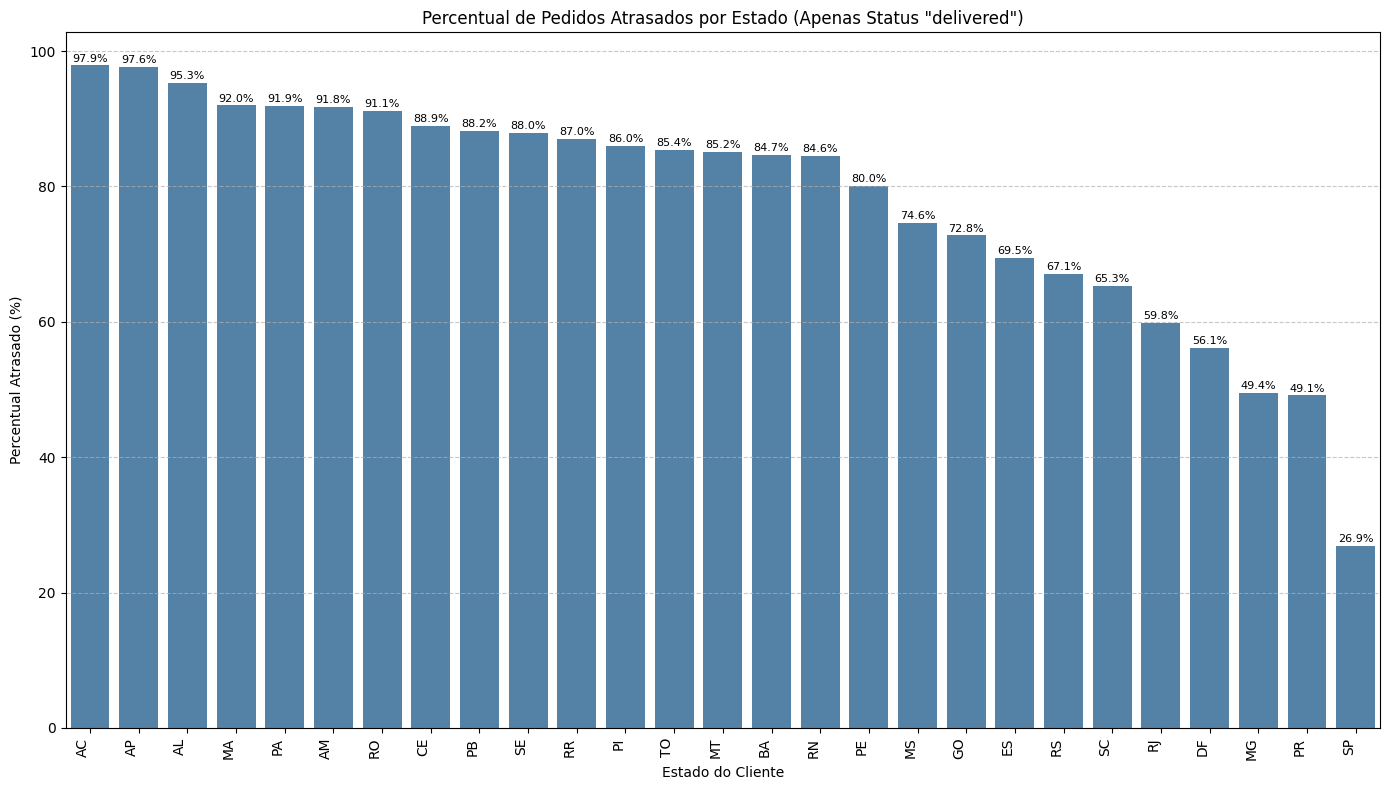

In [57]:
# =====================================================
# Estados com maior Percentual de Pedidos fora do leadtime
# =====================================================

# Calcular a % de pedidos que ultrapassaram os 10 dias de entrega por status de pedidos
leadtime_pedidos = (
    df_ajustado.groupby(['order_status', 'customer_state'])
    .agg(
        media_lead_real=('lead_real', 'mean'),
        percentual_atrasado=('lead_real', lambda x: (x > 10).mean() * 100) # Calcula a porcentagem
    )
    .reset_index()
)

# Filtrar pedidos somente para o status 'delivered'
# Criar um novo DataFrame filtrado para os pedidos 'delivered'
leadtime_pedidos_delivered = leadtime_pedidos[leadtime_pedidos['order_status'] == 'delivered'].copy()


# Ordenar o DataFrame filtrado pelo percentual de atraso antes de exibir
leadtime_pedidos_delivered = leadtime_pedidos_delivered.sort_values(by='percentual_atrasado', ascending=False)
display(leadtime_pedidos_delivered)

# Visualização dos dados:
plt.figure(figsize=(14, 8)) # Aumentar o tamanho do gráfico para melhor visualização dos estados
ax = sns.barplot(x='customer_state', y='percentual_atrasado', data=leadtime_pedidos_delivered, color='steelblue')
plt.title('Percentual de Pedidos Atrasados por Estado (Apenas Status "delivered")')
plt.xlabel('Estado do Cliente')
plt.ylabel('Percentual Atrasado (%)')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adicionar grade no eixo Y
plt.tight_layout()

# Adiciona os rótulos de dados (percentual) nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', # Formatando para duas casas decimais com símbolo de percentual
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5), # Ajuste o deslocamento vertical do rótulo
                textcoords='offset points',
                fontsize=8) # Diminuir o tamanho da fonte do rótulo

plt.show()